# 05. Test 비용 분석

03 노트북에서 저장한 `tuned stacking + threshold 0.32` 최종 모델을 불러와 `test_eda_fixed.csv` 기준 비용을 분석한다. 02와 동일하게 모델 없음 시 전체 지연 매출채권 회수 비용과 모델 적용 후 오류 비용을 비교한다.

In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


def setup_korean_font():
    def apply_font(font_name, source):
        plt.rcParams['font.family'] = [font_name]
        plt.rcParams['axes.unicode_minus'] = False
        sns.set_theme(style='whitegrid', rc={
            'font.family': [font_name],
            'axes.unicode_minus': False,
        })
        print(f'한글 폰트 설정: {font_name} ({source})')
        return font_name

    local_font_paths = [
        Path('assets/fonts/NanumGothic-Regular.ttf'),
        Path('../assets/fonts/NanumGothic-Regular.ttf'),
    ]
    for font_path in local_font_paths:
        if font_path.exists():
            fm.fontManager.addfont(str(font_path))
            font_name = fm.FontProperties(fname=str(font_path)).get_name()
            return apply_font(font_name, font_path)

    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans KR']
    available = {font.name for font in fm.fontManager.ttflist}
    for font_name in candidates:
        if font_name in available:
            return apply_font(font_name, 'system')

    plt.rcParams['axes.unicode_minus'] = False
    print('사용 가능한 한글 폰트를 찾지 못했다. assets/fonts/NanumGothic-Regular.ttf 파일을 확인한다.')
    return None


setup_korean_font()

한글 폰트 설정: NanumGothic (../assets/fonts/NanumGothic-Regular.ttf)


'NanumGothic'

## 모델과 Test 데이터 로드

In [2]:
PROJECT_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'data' / 'test_eda_fixed.csv').exists()
)
DATA_DIR = PROJECT_ROOT / 'data'
MODEL_PATH = PROJECT_ROOT / 'models' / 'stacking_tuned_threshold_032.joblib'
TEST_PATH = DATA_DIR / 'test_eda_fixed.csv'

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f'{MODEL_PATH} 파일이 없습니다. 먼저 03_hyperparameter_tuning.ipynb의 최종 Stacking 모델 저장 셀을 실행하세요.'
    )

artifact = joblib.load(MODEL_PATH)
test_raw = pd.read_csv(TEST_PATH)

DATE_COL = artifact['date_col']
TARGET_COL = artifact['target_col']
THRESHOLD = artifact['threshold']
DROP_COLS = artifact['drop_cols']
FEATURE_COLUMNS = artifact['feature_columns']

if DATE_COL in test_raw.columns:
    test_raw[DATE_COL] = pd.to_datetime(test_raw[DATE_COL])
    test_raw = test_raw.sort_values(DATE_COL).reset_index(drop=True)

print(f'로드 모델: {artifact["model_name"]}')
print(f'적용 threshold: {THRESHOLD:.2f}')
print(f'test 데이터: {test_raw.shape}')
print(f'기간: {test_raw[DATE_COL].min().date()} ~ {test_raw[DATE_COL].max().date()}')
display(test_raw[TARGET_COL].value_counts(normalize=True).sort_index().rename('target_ratio').to_frame())

로드 모델: tuned_stacking_threshold_032
적용 threshold: 0.32
test 데이터: (7832, 49)
기간: 2019-11-18 ~ 2020-03-06


,target_ratio
target,
0,0.945991
1,0.054009


In [3]:
def split_test_xy(df):
    if TARGET_COL not in df.columns:
        raise ValueError(f'test 데이터에 {TARGET_COL} 컬럼이 없어 비용 분석과 성능 평가를 할 수 없습니다.')

    drop_cols = [col for col in DROP_COLS if col in df.columns]
    model_df = df.drop(columns=drop_cols).copy()
    y = model_df[TARGET_COL].astype(int)
    X = model_df.drop(columns=TARGET_COL)

    missing_cols = [col for col in FEATURE_COLUMNS if col not in X.columns]
    if missing_cols:
        print('test에 없는 학습 피처를 NaN으로 추가:', missing_cols)
        for col in missing_cols:
            X[col] = np.nan

    extra_cols = [col for col in X.columns if col not in FEATURE_COLUMNS]
    if extra_cols:
        print('학습에 없던 test 피처는 제외:', extra_cols)

    X = X.reindex(columns=FEATURE_COLUMNS)
    return X, y


X_test, y_test = split_test_xy(test_raw)
print(f'test 사용 피처 수: {X_test.shape[1]}')

test 사용 피처 수: 37


## Test 예측 성능

In [4]:
def predict_stacking_proba(artifact, X):
    base_model_order = artifact['base_model_order']
    base_proba = np.column_stack([
        artifact['base_models'][model_name].predict_proba(X)[:, 1]
        for model_name in base_model_order
    ])
    stacking_proba = artifact['meta_model'].predict_proba(base_proba)[:, 1]
    return stacking_proba, base_proba


test_proba, test_base_proba = predict_stacking_proba(artifact, X_test)
test_pred = (test_proba >= THRESHOLD).astype(int)

print('=' * 70)
print(f'[Tuned stacking threshold={THRESHOLD:.2f}] test 성능')
print(f'Accuracy : {accuracy_score(y_test, test_pred):.4f}')
print(f'Macro F1 : {f1_score(y_test, test_pred, average="macro"):.4f}')
print(f'ROC AUC  : {roc_auc_score(y_test, test_proba):.4f}')
print()
print('분류 리포트')
print(classification_report(y_test, test_pred, labels=[0, 1]))
print('Confusion matrix')  # 행: 실제값, 열: 예측값, labels=[0, 1] 순서
print(confusion_matrix(y_test, test_pred, labels=[0, 1]))

[Tuned stacking threshold=0.32] test 성능
Accuracy : 0.9581
Macro F1 : 0.7674
ROC AUC  : 0.8771

분류 리포트
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      7409
           1       0.65      0.49      0.56       423

    accuracy                           0.96      7832
   macro avg       0.81      0.74      0.77      7832
weighted avg       0.95      0.96      0.96      7832

Confusion matrix
[[7298  111]
 [ 217  206]]


## Test ROC AUC Curve


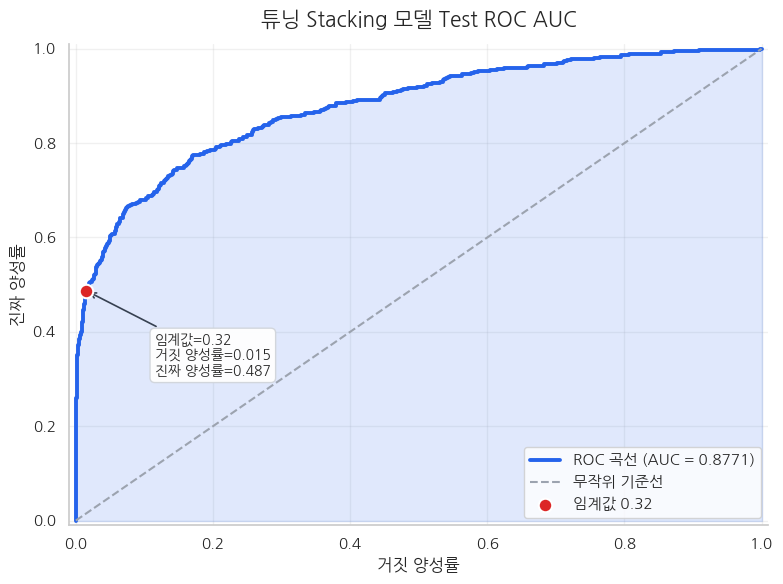

In [10]:
from sklearn.metrics import roc_curve

fpr, tpr, roc_thresholds = roc_curve(y_test, test_proba)
test_auc = roc_auc_score(y_test, test_proba)

threshold_idx = np.argmin(np.abs(roc_thresholds - THRESHOLD))
threshold_fpr = fpr[threshold_idx]
threshold_tpr = tpr[threshold_idx]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#2563EB', linewidth=2.8, label=f'ROC 곡선 (AUC = {test_auc:.4f})')
ax.fill_between(fpr, tpr, alpha=0.14, color='#2563EB')
ax.plot([0, 1], [0, 1], linestyle='--', color='#9CA3AF', linewidth=1.5, label='무작위 기준선')
ax.scatter(
    threshold_fpr,
    threshold_tpr,
    s=95,
    color='#DC2626',
    edgecolor='white',
    linewidth=1.5,
    zorder=5,
    label=f'임계값 {THRESHOLD:.2f}',
)
ax.annotate(
    f'임계값={THRESHOLD:.2f}\n거짓 양성률={threshold_fpr:.3f}\n진짜 양성률={threshold_tpr:.3f}',
    xy=(threshold_fpr, threshold_tpr),
    xytext=(min(threshold_fpr + 0.10, 0.72), max(threshold_tpr - 0.18, 0.12)),
    arrowprops=dict(arrowstyle='->', color='#374151', linewidth=1.2),
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#D1D5DB', alpha=0.95),
    fontsize=10,
)

ax.set_title('튜닝 Stacking 모델 Test ROC AUC', fontsize=15, pad=12)
ax.set_xlabel('거짓 양성률')
ax.set_ylabel('진짜 양성률')
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.grid(True, alpha=0.28)
ax.legend(loc='lower right', frameon=True)
sns.despine(ax=ax)
plt.tight_layout()


## Test 기준 비용-편익 분석

In [5]:
COST_FIXED_FP = artifact.get('cost_config', {}).get('fixed_fp_cost', 23.0)


def recovery_cost_per_1000(delay_days):
    if delay_days <= 30:
        return 1.5
    if delay_days <= 60:
        return 5.0
    if delay_days <= 90:
        return 8.0
    return 10.5


def make_test_cost_frame(pred, pred_proba, scenario):
    frame = test_raw.copy().reset_index(drop=True)
    frame['y_true'] = y_test.reset_index(drop=True).values
    frame['y_pred'] = np.asarray(pred).astype(int)
    frame['pred_proba'] = np.asarray(pred_proba)
    frame['scenario'] = scenario
    frame['delay_days'] = frame['business_days_late'].clip(lower=0)
    frame['amount_usd_actual'] = np.expm1(frame['amount_in_usd'])

    frame['is_fn'] = (frame['y_true'] == 1) & (frame['y_pred'] == 0)
    frame['is_fp'] = (frame['y_true'] == 0) & (frame['y_pred'] == 1)
    frame['is_tp'] = (frame['y_true'] == 1) & (frame['y_pred'] == 1)
    frame['is_tn'] = (frame['y_true'] == 0) & (frame['y_pred'] == 0)

    frame['cost_per_1000'] = frame['delay_days'].apply(recovery_cost_per_1000)
    frame['fn_recovery_cost'] = np.where(
        frame['is_fn'],
        frame['amount_usd_actual'] / 1000 * frame['cost_per_1000'],
        0.0,
    )
    frame['fp_fixed_cost'] = np.where(frame['is_fp'], COST_FIXED_FP, 0.0)
    frame['total_error_cost'] = frame['fn_recovery_cost'] + frame['fp_fixed_cost']
    return frame


def summarize_model_cost(frame):
    return {
        'scenario': frame['scenario'].iloc[0],
        'threshold': THRESHOLD,
        'accuracy': accuracy_score(frame['y_true'], frame['y_pred']),
        'macro_f1': f1_score(frame['y_true'], frame['y_pred'], average='macro'),
        'roc_auc': roc_auc_score(frame['y_true'], frame['pred_proba']),
        'tp': int(frame['is_tp'].sum()),
        'tn': int(frame['is_tn'].sum()),
        'fp': int(frame['is_fp'].sum()),
        'fn': int(frame['is_fn'].sum()),
        'fn_recovery_cost': frame['fn_recovery_cost'].sum(),
        'fp_fixed_cost': frame['fp_fixed_cost'].sum(),
        'total_error_cost': frame['total_error_cost'].sum(),
    }


model_cost_df = make_test_cost_frame(
    test_pred,
    test_proba,
    f'Tuned stacking threshold={THRESHOLD:.2f}',
)
model_summary = pd.DataFrame([summarize_model_cost(model_cost_df)])
display(model_summary)

,scenario,threshold,accuracy,macro_f1,roc_auc,tp,tn,fp,fn,fn_recovery_cost,fp_fixed_cost,total_error_cost
0,Tuned stacking threshold=0.32,0.32,0.958121,0.767389,0.877117,206,7298,111,217,11084.302351,2553.0,13637.302351


In [6]:
# 모델이 없으면 실제 지연 건(target=1)을 모두 회수 대상으로 보고 06과 같은 방식으로 총 회수 비용을 계산한다.
no_model_df = test_raw.copy().reset_index(drop=True)
no_model_df['y_true'] = y_test.reset_index(drop=True).values
no_model_df['delay_days'] = no_model_df['business_days_late'].clip(lower=0)
no_model_df['amount_usd_actual'] = np.expm1(no_model_df['amount_in_usd'])

actual_delayed_df = no_model_df[no_model_df['y_true'] == 1].copy()
actual_delayed_df['cost_per_1000'] = actual_delayed_df['delay_days'].apply(recovery_cost_per_1000)
actual_delayed_df['recovery_cost'] = actual_delayed_df['amount_usd_actual'] / 1000 * actual_delayed_df['cost_per_1000']

no_model_total_cost = actual_delayed_df['recovery_cost'].sum()
model_total_error_cost = model_summary.loc[0, 'total_error_cost']

comparison_df = pd.DataFrame([
    {
        'scenario': '모델 없음(지연 매출채권 전체 회수)',
        'total_cost': no_model_total_cost,
        'fn_recovery_cost': no_model_total_cost,
        'fp_fixed_cost': 0.0,
        'cost_saving_vs_no_model': 0.0,
        'cost_saving_rate': 0.0,
    },
    {
        'scenario': f'Tuned stacking threshold={THRESHOLD:.2f}',
        'total_cost': model_total_error_cost,
        'fn_recovery_cost': model_summary.loc[0, 'fn_recovery_cost'],
        'fp_fixed_cost': model_summary.loc[0, 'fp_fixed_cost'],
        'cost_saving_vs_no_model': no_model_total_cost - model_total_error_cost,
        'cost_saving_rate': (no_model_total_cost - model_total_error_cost) / no_model_total_cost if no_model_total_cost > 0 else 0.0,
    },
])

display(comparison_df)
print(f"test 지연 매출채권 건수(target=1): {len(actual_delayed_df):,}")
print(f"모델 없음(지연 매출채권 전체) 총 회수 비용: ${no_model_total_cost:,.0f}")
print(f"Tuned stacking threshold={THRESHOLD:.2f} 총 오류 비용: ${model_total_error_cost:,.0f}")
print(f"모델 적용 시 비용 차이: ${no_model_total_cost - model_total_error_cost:,.0f}")
print(f"모델 적용 시 비용 절감률: {comparison_df.loc[1, 'cost_saving_rate']:.2%}")

,scenario,total_cost,fn_recovery_cost,fp_fixed_cost,cost_saving_vs_no_model,cost_saving_rate
0,모델 없음(지연 매출채권 전체 회수),21626.235525,21626.235525,0.0,0.000000,0.000000
1,Tuned stacking threshold=0.32,13637.302351,11084.302351,2553.0,7988.933174,0.369409


test 지연 매출채권 건수(target=1): 423
모델 없음(지연 매출채권 전체) 총 회수 비용: $21,626
Tuned stacking threshold=0.32 총 오류 비용: $13,637
모델 적용 시 비용 차이: $7,989
모델 적용 시 비용 절감률: 36.94%


## 비용과 Confusion Matrix 시각화

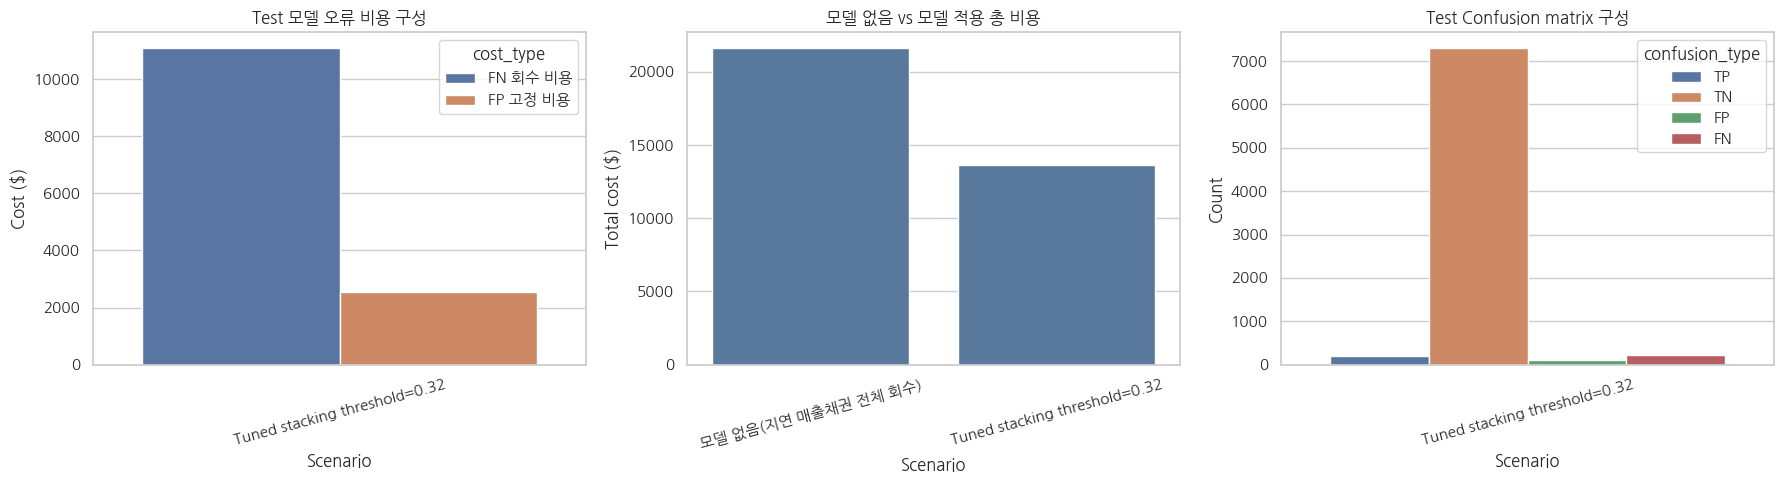

In [7]:
model_cost_plot_df = model_summary.melt(
    id_vars='scenario',
    value_vars=['fn_recovery_cost', 'fp_fixed_cost'],
    var_name='cost_type',
    value_name='cost',
)
model_cost_plot_df['cost_type'] = model_cost_plot_df['cost_type'].map({
    'fn_recovery_cost': 'FN 회수 비용',
    'fp_fixed_cost': 'FP 고정 비용',
})

comparison_plot_df = comparison_df.copy()
confusion_plot_df = model_summary.melt(
    id_vars='scenario',
    value_vars=['tp', 'tn', 'fp', 'fn'],
    var_name='confusion_type',
    value_name='count',
)
confusion_plot_df['confusion_type'] = confusion_plot_df['confusion_type'].str.upper()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=model_cost_plot_df, x='scenario', y='cost', hue='cost_type', ax=axes[0])
axes[0].set_title('Test 모델 오류 비용 구성')
axes[0].set_xlabel('시나리오')
axes[0].set_ylabel('비용 ($)')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=comparison_plot_df, x='scenario', y='total_cost', ax=axes[1], color='#4C78A8')
axes[1].set_title('모델 없음 vs 모델 적용 총 비용')
axes[1].set_xlabel('시나리오')
axes[1].set_ylabel('총 비용 ($)')
axes[1].tick_params(axis='x', rotation=15)

sns.barplot(data=confusion_plot_df, x='scenario', y='count', hue='confusion_type', ax=axes[2])
axes[2].set_title('Test 혼동행렬 구성')
axes[2].set_xlabel('시나리오')
axes[2].set_ylabel('건수')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()

FN 건수: 217


,cust_number,amount_usd_actual,delay_days,cost_per_1000,pred_proba,fn_recovery_cost
5295,0140104440,255047.7000,6,1.5,0.075952,382.571550
6687,0200014556,74975.9000,59,5.0,0.025961,374.879500
556,0100036066,154808.6400,7,1.5,0.034083,232.212960
7005,0200084659,145246.9200,6,1.5,0.071518,217.870380
5660,0100053562,40370.0600,32,5.0,0.125202,201.850300
4953,0200762301,130230.0600,7,1.5,0.029511,195.345090
903,0140105847,120127.1250,6,1.5,0.041711,180.190688
75,0140104409,113550.5475,15,1.5,0.034683,170.325821
4936,0200793830,109917.2600,8,1.5,0.027929,164.875890
6535,0100031704,109632.9900,18,1.5,0.027183,164.449485


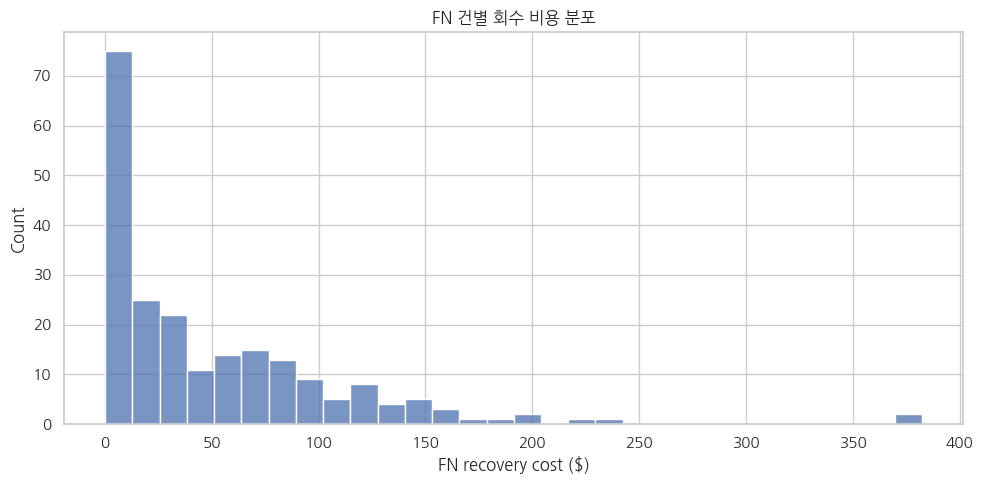

In [8]:
# 비용이 큰 FN을 확인해 총 비용이 어떤 건에서 발생했는지 점검한다.
fn_detail_df = model_cost_df[model_cost_df['is_fn']].copy()
fn_detail_df = fn_detail_df.sort_values('fn_recovery_cost', ascending=False)

cols = [
    'cust_number', 'amount_usd_actual', 'delay_days', 'cost_per_1000',
    'pred_proba', 'fn_recovery_cost',
]
print(f'FN 건수: {len(fn_detail_df):,}')
display(fn_detail_df[[col for col in cols if col in fn_detail_df.columns]].head(20))

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=fn_detail_df, x='fn_recovery_cost', bins=30, ax=ax)
ax.set_title('FN 건별 회수 비용 분포')
ax.set_xlabel('FN 회수 비용 ($)')
ax.set_ylabel('건수')
plt.tight_layout()